In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_csv("ToyotaCorolla - MLR.csv")

In [3]:
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


In [4]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [5]:
df.tail()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015
1435,6950,76,1,Petrol,110,0,1600,5,4,5,1114


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [7]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


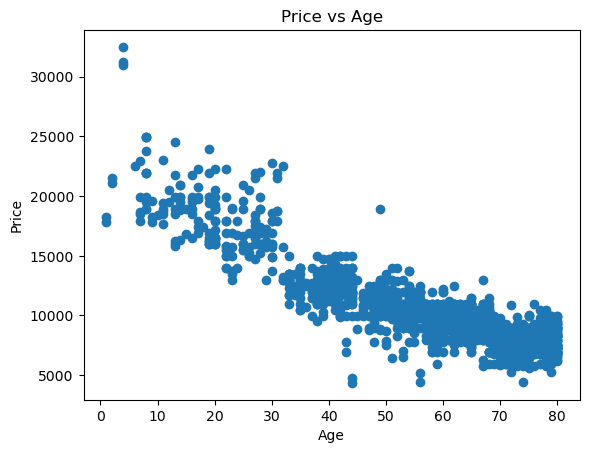

In [9]:
plt.scatter(df["Age_08_04"], df["Price"])
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age")
plt.show()

In [11]:
df = pd.get_dummies(df, columns=["Fuel_Type"], drop_first=True)
df.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


In [12]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [25]:
pred1 = model.predict(X_test)

In [26]:
pred1

array([11137.15453645,  8974.9731327 ,  9283.27025955,  8951.97440751,
       10082.31592852,  7959.3269862 ,  8656.43768303,  8254.87283979,
       14063.40319186, 13099.95735642,  9551.42647033,  9325.01973397,
       12919.13152502, 12925.08574757,  9793.37148737,  8305.77313577,
       12190.02678644, 17535.47631867,  7469.10553333,  9146.75133486,
       12638.29998775, 17804.25328461,  7903.43441681, 10386.01442865,
        7580.43295913, 16058.83988677, 10034.10324597,  7412.37291567,
       15766.17628452, 14440.45886039,  8163.90729602,  9609.36755541,
        8509.88035778, 10098.71270421, 10245.63943307,  8073.58357557,
        8759.24335824,  9965.93592783, 16471.77872927,  9624.35819079,
        9829.937657  ,  9503.46762021,  7888.13705539,  5698.36965348,
        6870.22880548, 17266.12085347,  9441.28892372, 10702.0580487 ,
        8748.50876678, 13429.13420122, 12940.89346452,  6393.20092254,
       15071.98364029, 16374.4739198 ,  6194.47032501,  7783.01004642,
      

In [27]:
r2_score(y_test, pred1)

0.8348888040611082

In [29]:
mean_squared_error(pred1,y_test)

2203043.823143704

In [30]:
np.sqrt(mean_squared_error(pred1,y_test))

np.float64(1484.265415329652)

In [31]:
mean_absolute_error(y_test,pred1)

990.8872739193968

In [32]:
x2 = df[["KM","HP","cc","Doors","Gears"]]
y2 = df["Price"]

In [34]:
x2_train,x2_test,y2_train,y2_test = train_test_split(x2 , y2 , test_size=0.2 , random_state= 42)

In [35]:
slr1 = StandardScaler()

In [36]:
x2_train=slr1.fit_transform(x2_train)

In [37]:
x2_test = slr1.transform(x2_test)

In [38]:
model2 = LinearRegression()

In [39]:
model2.fit(x2_train,y2_train)

LinearRegression()

In [41]:
pred2= model2.predict(x2_test)
pred2

array([12262.9981864 ,  9739.49788298,  7369.36973581, 11104.30269073,
       12001.50055517, 10150.15915006, 10335.08319938, 10961.95636146,
       12373.83766892, 13142.05014627, 10191.48302817, 10877.67253855,
       12582.04034982, 12183.25312915,  9650.35863633,  9919.57554159,
       11362.01409279,  9895.06867483,  7228.39938942, 11737.61883034,
       11519.74955142, 14206.65031351, 10184.19136567, 11392.18849443,
        8972.77643976, 13923.87892061, 10013.20930445,  7436.8131757 ,
       13040.29672197, 13599.83216251,  9487.5436121 , 12258.78523689,
       11238.35460694, 10278.2388124 , 10755.97028705,  9558.79167781,
       10304.42014295, 10239.39542251, 12977.28176608,  9333.8146461 ,
       10975.83654018, 10700.08013773, 10788.27793706,  5370.41293442,
        9180.70671204, 13050.95817485, 10105.02684822, 11266.43162247,
       10573.36890304, 13819.48731027, 12419.7973385 ,  9594.05104583,
       11568.89222427, 13398.79853764,  6590.60203007, 10053.57843877,
      

In [42]:
r2_score(y2_test,pred2)

0.4321501019847478

In [43]:
mean_squared_error(y2_test,pred2)

7576701.284135097

In [44]:
np.sqrt(mean_squared_error(y2_test,pred2))

np.float64(2752.5808406176006)

In [46]:
mean_absolute_error(y2_test,pred2)

1995.7484745911668

In [47]:
ridge = Ridge(alpha=1.0)

In [48]:
ridge.fit(X_train,y_train)

Ridge()

In [49]:
ridge_pred = ridge.predict(X_test)

In [50]:
ridge_pred

array([11138.15019313,  8975.24595559,  9283.99386946,  8953.86252887,
       10084.00967305,  7960.8062846 ,  8658.17434038,  8257.40180876,
       14061.50500762, 13099.83201035,  9551.24425227,  9326.26838943,
       12918.63408363, 12924.1796782 ,  9792.71231946,  8306.47366925,
       12188.90704867, 17529.77622626,  7468.06680538,  9149.18244012,
       12637.24543706, 17800.06829487,  7905.31074179, 10386.75237723,
        7580.65886165, 16055.93966577, 10033.33361953,  7411.63509836,
       15762.00427294, 14439.61180249,  8164.80548214,  9612.6350875 ,
        8512.37230549, 10098.57767409, 10245.91399381,  8074.55703287,
        8760.93954063,  9965.88981838, 16466.81934866,  9623.39808031,
        9830.88961841,  9504.42760475,  7890.7320173 ,  5696.39212524,
        6871.51809464, 17260.68142079,  9441.61650595, 10702.26600409,
        8749.52539327, 13429.46744324, 12940.28646986,  6395.45571764,
       15066.7945435 , 16370.24619894,  6193.41672207,  7784.85287807,
      

In [51]:
lasso = Lasso(alpha=0.1)

In [52]:
lasso.fit(X_train,y_train)

Lasso(alpha=0.1)

In [53]:
lasso_pred = lasso.predict(X_test)
lasso_pred

array([11137.21267894,  8974.87199914,  9283.65980524,  8952.13886093,
       10082.45726494,  7959.35444859,  8656.64634957,  8254.85719066,
       14063.5133654 , 13100.06290858,  9551.39887296,  9324.9506912 ,
       12919.26058786, 12925.12211311,  9793.25872721,  8305.76920825,
       12190.04477127, 17535.20977621,  7468.980711  ,  9146.9336446 ,
       12638.33309924, 17804.01488448,  7903.3588404 , 10386.05322631,
        7580.59014287, 16058.66373973, 10033.76703632,  7412.25527146,
       15765.88247312, 14440.6036008 ,  8163.84617017,  9609.83575467,
        8510.0537984 , 10098.65564534, 10245.59584382,  8073.48646032,
        8759.48915847,  9965.87907567, 16471.47532975,  9624.4204062 ,
        9829.90547449,  9503.43026656,  7888.30301373,  5698.25048152,
        6870.21706462, 17265.78657122,  9441.23349066, 10702.16954655,
        8748.52066913, 13429.25755179, 12940.83405242,  6393.20734542,
       15071.65094651, 16373.89866123,  6194.38425434,  7783.15398804,
      